### Quick Start Code Cell

In [1]:
savefile_path = '/Users/austin/Desktop/2026_05_08_coolingSeries/'

In [2]:
import subprocess
import time
import os
import tango
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

from skimage.feature import peak_local_max
from scipy.ndimage import gaussian_filter, center_of_mass

In [3]:
# first do lsof -i:9000
# kill {PID}

# if kernel is dying, reset the environment (click a different one then click back)

In [4]:
# ── Config ────────────────────────────────────────────────────────────────────
DB_HOST = "localhost"
DB_PORT = 9000
server_list = [("stage", "asyncroscopy.hardware.STAGE"),
                     ("scan", "asyncroscopy.hardware.SCAN"),
                     ("eds", "asyncroscopy.detectors.EDS"),
                     ("camera", "asyncroscopy.detectors.CAMERA")]
# ─────────────────────────────────────────────────────────────────────────────

PROJECT_DIR = os.path.dirname(os.getcwd())
os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"
env = {**os.environ, "TANGO_HOST": f"{DB_HOST}:{DB_PORT}"}
processes = {}

def popen(cmd):
    return subprocess.Popen(cmd, env=env, cwd=PROJECT_DIR, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

def wait_for_device(name, timeout=60, interval=1):
    print(f"  Waiting for {name}...", end="", flush=True)
    start = time.time()
    while time.time() - start < timeout:
        try:
            tango.DeviceProxy(name).ping()
            print(f" ✅ ready ({time.time()-start:.1f}s)"); return True
        except:
            print(".", end="", flush=True); time.sleep(interval)
    print(f" ❌ timed out after {timeout}s"); return False

def check_processes(*names):
    for name in names:
        p = processes[name]
        print(f"\n─── {name} (PID {p.pid}) ───\n  Running: {p.poll() is None}")
        for label, fd in [("STDOUT", p.stdout), ("STDERR", p.stderr)]:
            try: print(f"  {label}: {fd.read1(4096).decode() or '(empty)'}")
            except: print(f"  {label}: (no output yet)")

# Kill old processes (if any)
print("Clearing old processes...")
for cmd in [f"kill -9 $(lsof -t -i:{DB_PORT}) 2>/dev/null || true",
            *[f"pkill -f '{module.split('.')[-1]} {name}_instance' 2>/dev/null || true"
              for name, module in server_list],
            "pkill -f 'ThermoMicroscope microscope_instance' 2>/dev/null || true"]:
    subprocess.run(cmd, shell=True)
time.sleep(2)

# Start DB
print(f"Project dir: {PROJECT_DIR}\nStarting Tango Database...")
processes["database"] = popen(["uv", "run", "python", "-m", "tango.databaseds.database", "2"])
print("  Waiting for database...", end="", flush=True)
for _ in range(30):
    try: tango.Database(DB_HOST, DB_PORT); print(" ✅ ready"); break
    except: print(".", end="", flush=True); time.sleep(1)

# Register devices
print("Registering devices...")
r = subprocess.run(["uv", "run", "scripts/2_register_devices.py"], env=env, cwd=PROJECT_DIR, capture_output=True, text=True)
print(r.stdout.strip())
if r.returncode != 0:
    print("ERROR:", r.stderr); raise RuntimeError("Device registration failed — stopping here.")

# Start servers
print("Starting device servers...")
for name, module in server_list:
    processes[name] = popen(["uv", "run", "python", "-m", module, f"{name}_instance"])

if not all(wait_for_device(f"asyncroscopy/{d}/default") for d in ["stage", "scan", "eds"]):
    raise RuntimeError("Stage/Scan/EDS server failed.")

print("Starting Microscope...")
processes["microscope"] = popen(["uv", "run", "python", "-m", "asyncroscopy.ThermoMicroscope", "microscope_instance"])
if not wait_for_device("asyncroscopy/microscope/default"):
    print("\n⚠️  Debug info:"); check_processes("microscope")
    raise RuntimeError("Microscope server failed — see debug info above.")

print("\n✅ All servers ready!")

Clearing old processes...
Project dir: /Users/austin/Documents/GitHub/asyncroscopy
Starting Tango Database...
  Waiting for database.... ✅ ready
Registering devices...
Connected: stingray-zm68g.device.utk.edu:9000

  registered: asyncroscopy/scan/default
  registered: asyncroscopy/camera/default
  registered: asyncroscopy/eds/default
  registered: asyncroscopy/stage/default
  registered: asyncroscopy/corrector/default
  registered: asyncroscopy/microscope/default
  property:   scan_device_address = asyncroscopy/scan/default
  property:   camera_device_address = asyncroscopy/camera/default
  property:   eds_device_address = asyncroscopy/eds/default
  property:   stage_device_address = asyncroscopy/stage/default
  property:   corrector_device_address = asyncroscopy/corrector/default

Done!
Starting device servers...
  Waiting for asyncroscopy/stage/default.... ✅ ready (1.0s)
  Waiting for asyncroscopy/scan/default... ✅ ready (0.0s)
  Waiting for asyncroscopy/eds/default... ✅ ready (0.0s)

## 1. Connect to devices

In [5]:
# Tango DB running on this
os.environ["TANGO_HOST"] = "localhost:9000"
# os.environ["TANGO_HOST"] = "10.46.217.241:9094"

# list devices on DB
db = tango.Database()
devices = db.get_device_name("*", "*")
print("Devices registered in Tango DB:\n")
for d in devices:
    print(d)

Devices registered in Tango DB:

asyncroscopy/detector/haadf
asyncroscopy/microscope/thermo
dserver/CAMERA/camera_instance
dserver/CORRECTOR/corrector_instance
dserver/DataBaseds/2
dserver/DetectorServer/detectors
dserver/EDS/eds_instance
dserver/HAADF/haadf_instance
dserver/MicroscopeServer/microscope
dserver/SCAN/scan_instance
dserver/STAGE/eds_instance
dserver/STAGE/stage_instance
dserver/TangoAccessControl/1
dserver/TangoTest/test
dserver/ThermoMicroscope/microscope_instance
sys/access_control/1
sys/database/2
sys/tg_test/1
asyncroscopy/camera/default
asyncroscopy/corrector/default
asyncroscopy/eds/default
asyncroscopy/microscope/default
asyncroscopy/scan/default
asyncroscopy/stage/default


In [6]:
scan = tango.DeviceProxy("asyncroscopy/scan/default")
mic = tango.DeviceProxy("asyncroscopy/microscope/default")

scan.set_timeout_millis(120_000)
mic.set_timeout_millis(120_000)

In [7]:
## helper funcs.
def get_image(dwell=10e-6, imsize=512):
    scan.dwell_time = dwell
    scan.imsize  = imsize

    json_meta, raw_bytes = mic.get_scanned_image()
    metadata  = dict(json.loads(json_meta))
    image = np.frombuffer(raw_bytes, dtype=metadata['dtype']).reshape(metadata['shape'])

    return image, metadata

### Begin

Stage position: [-7.4462652e-05  1.4732667e-04  8.1138147e-05  9.0551002e-05]


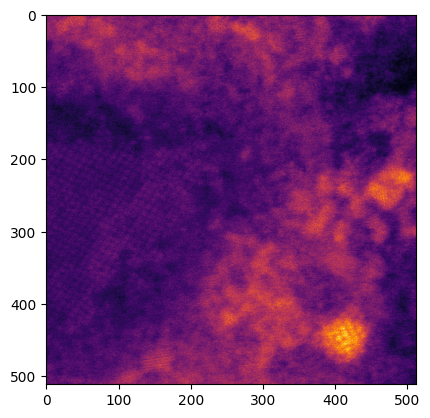

In [8]:
# Get image
starting_image, metadata = get_image()
plt.figure()
plt.imshow(starting_image, cmap='inferno')

# Get Stage
starting_position = mic.get_stage()
print('Stage position:', starting_position)

In [60]:
# First time will take ~35 seconds:
mic.set_screen_current(200) # pA


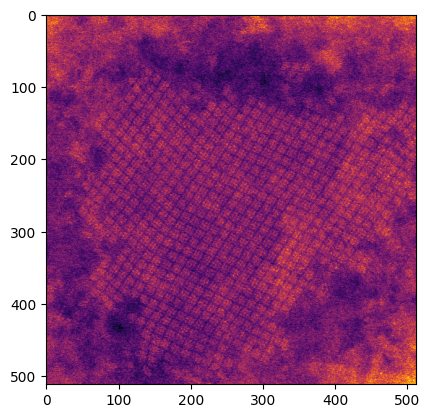

In [10]:
# Get image
starting_image, metadata = get_image()
plt.figure()
plt.imshow(starting_image, cmap='inferno')

In [61]:
set_current_high = 200  # pA
set_current_low  = 50   # pA

high_current_frames = 5
low_current_frames  = 20

delay_between_low_frames = 5  # seconds

real_currents = []
meta_images = []

# ------------------------------------------------------------
# 1) initial high-current burst
# ------------------------------------------------------------
print(f"\nSetting screen current to {set_current_high} pA...")
mic.set_screen_current(set_current_high)

time.sleep(1)  # stabilization

real_screen_current = mic.get_screen_current() * 1e12
real_currents.append(real_screen_current)

# mic.auto_focus()

high_images = []

for i in range(high_current_frames):
    image, metadata = get_image(dwell=10e-6, imsize=512)
    high_images.append(image)

meta_images.append(high_images)

# ------------------------------------------------------------
# 2) switch to low current
# ------------------------------------------------------------
print(f"\nSetting screen current to {set_current_low} pA...")
mic.set_screen_current(set_current_low)

time.sleep(1)

real_screen_current = mic.get_screen_current() * 1e12
real_currents.append(real_screen_current)

# optional autofocus after switching currents
mic.auto_focus()

low_images = []

for i in range(low_current_frames):

    print(f"Acquiring low-current frame {i+1}/{low_current_frames}")

    image, metadata = get_image(dwell=10e-6, imsize=512)
    low_images.append(image)

    # wait 10 seconds before next frame
    if i < low_current_frames - 1:
        time.sleep(delay_between_low_frames)

meta_images.append(low_images)


Setting screen current to 200 pA...


KeyboardInterrupt: 

In [45]:
# ------------------------------------------------------------
# convert to object array so unequal lengths are preserved
# ------------------------------------------------------------
meta_images_array = np.array(meta_images, dtype=object)

# ------------------------------------------------------------
# construct experiment metadata / recipe
# ------------------------------------------------------------
recipe = {
    "high_current_pA": set_current_high,
    "low_current_pA": set_current_low,
    "high_current_frames": high_current_frames,
    "low_current_frames": low_current_frames,
    "delay_between_low_frames_s": delay_between_low_frames,
    "image_size": 512,
    "dwell_time_s": 10e-6,
    "focus_performed": True,
    "timestamp": datetime.now().isoformat(),
}

# ------------------------------------------------------------
# save everything
# ------------------------------------------------------------
filename = os.path.join(savefile_path, "beam_cooling_3.npz")

np.savez(
    filename,

    # image data
    images=meta_images_array,

    # measured currents
    real_currents_pA=np.array(real_currents),

    # acquisition recipe
    recipe=recipe,

    # convenience fields
    high_current_pA=set_current_high,
    low_current_pA=set_current_low,
    high_current_frames=high_current_frames,
    low_current_frames=low_current_frames,
    delay_between_low_frames_s=delay_between_low_frames,
)

print(f"Saved dataset to:\n{filename}")

Saved dataset to:
/Users/austin/Desktop/2026_05_08_coolingSeries/beam_cooling_3.npz


In [46]:
def detect_blobs(im):
    p99 = np.percentile(im.ravel(), 99)
    im = np.clip(im, 0, p99)
    smoothed = gaussian_filter(im, sigma=3)
    smoothed -= smoothed.min()
    smoothed /= smoothed.max()
    blobs = peak_local_max(smoothed, min_distance=5, threshold_abs=0.1)
    return blobs

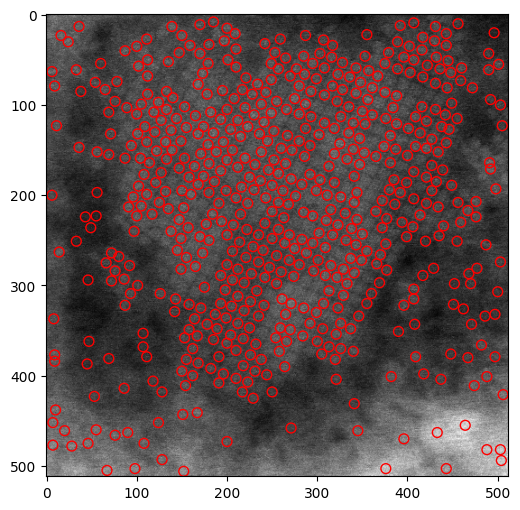

In [47]:
im = meta_images[0][0]

blobs = detect_blobs(im)

plt.figure(figsize=(6, 6))
plt.imshow(im, cmap='gray')
plt.scatter(blobs[:, 1], blobs[:, 0], s=50, edgecolor='red', facecolor='none')

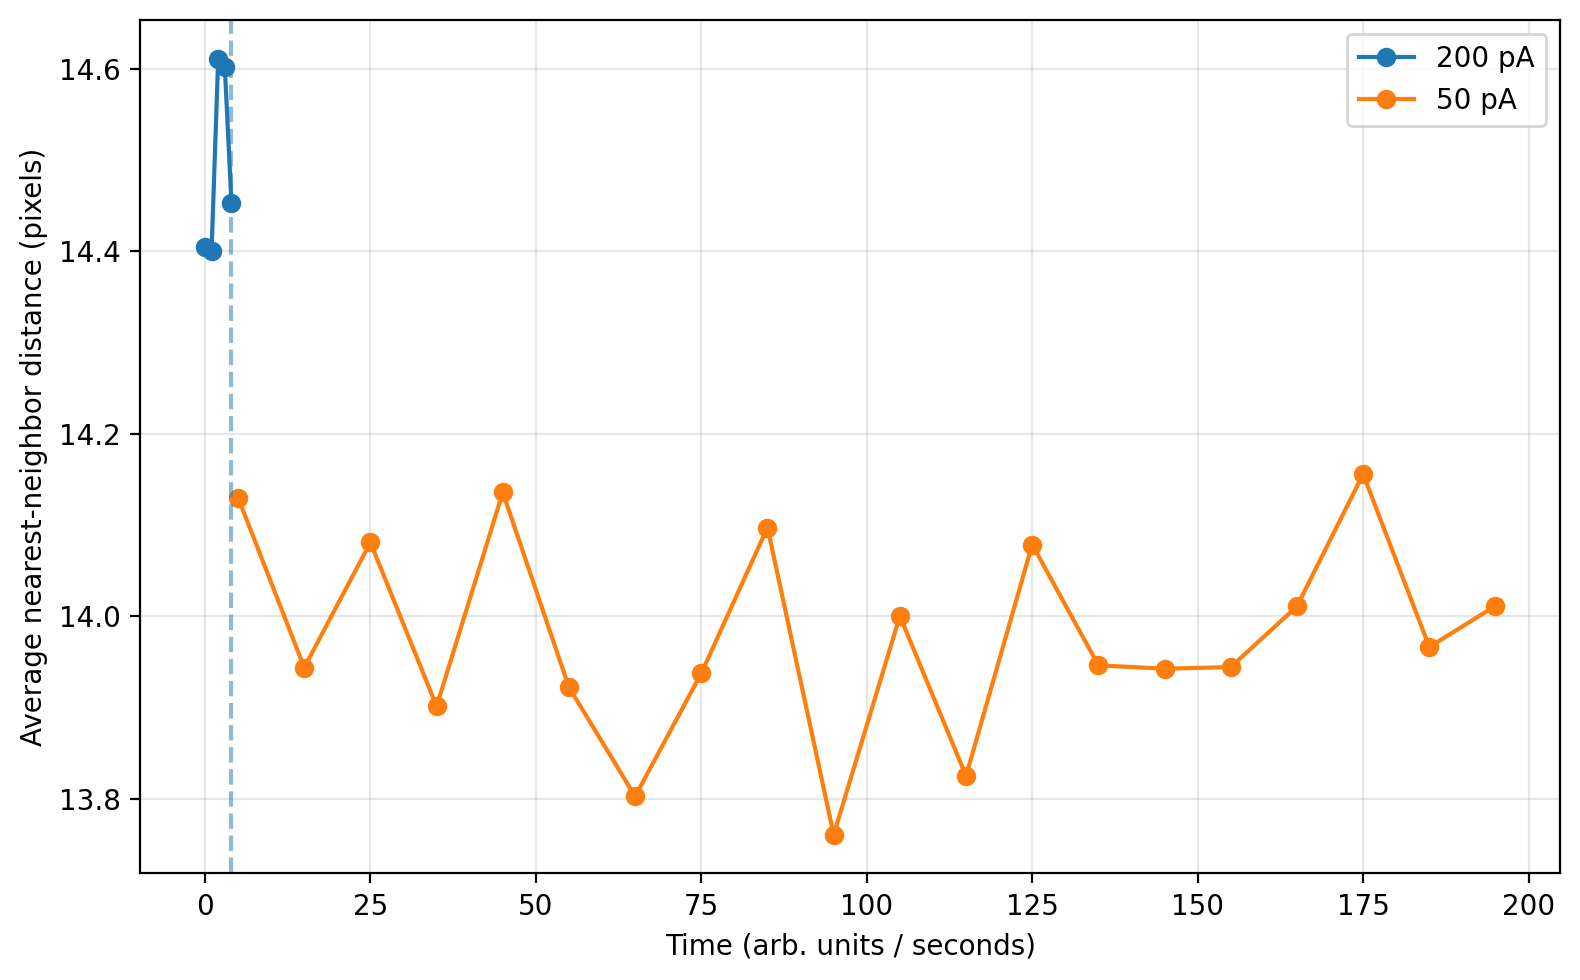

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree


# ------------------------------------------------------------
# helper: average nearest-neighbor distance for one image
# ------------------------------------------------------------
def average_nn_distance(image):

    blobs = detect_blobs(image)

    if blobs is None or len(blobs) < 2:
        return np.nan

    tree = cKDTree(blobs)

    # k=2 because first neighbor is self
    dists, _ = tree.query(blobs, k=2)

    nn_dists = dists[:, 1]

    return np.mean(nn_dists)


# ------------------------------------------------------------
# compute NN distances
# ------------------------------------------------------------
high_nn = []
low_nn  = []

# 10 frames at 200 pA
for im in meta_images[0]:
    high_nn.append(average_nn_distance(im))

# 30 frames at 50 pA
for im in meta_images[1]:
    low_nn.append(average_nn_distance(im))

high_nn = np.array(high_nn)
low_nn  = np.array(low_nn)


# ------------------------------------------------------------
# construct time axis
# ------------------------------------------------------------
# assume high-current frames are acquired rapidly
high_times = np.arange(len(high_nn))

# low-current frames every 10 seconds
low_times = high_times[-1] + 1 + np.arange(len(low_nn)) * 10


# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), dpi=200)

ax.plot(
    high_times,
    high_nn,
    marker='o',
    linewidth=1.5,
    label='200 pA'
)

ax.plot(
    low_times,
    low_nn,
    marker='o',
    linewidth=1.5,
    label='50 pA'
)

# vertical line showing current switch
ax.axvline(
    high_times[-1],
    linestyle='--',
    alpha=0.5
)

ax.set_xlabel("Time (arb. units / seconds)")
ax.set_ylabel("Average nearest-neighbor distance (pixels)")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [56]:
mic.set_screen_current(50)

In [65]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from datetime import datetime

# ============================================================
# experiment recipe
# ============================================================
set_currents_pA = []
frames_per_current = 10

dwell_time_s = 10e-6
imsize = 512
stabilization_time_s = 1

filename = os.path.join(savefile_path, "ramp_stop_andmeasure_later_newXtal.npz")

# ============================================================
# helper: average nearest-neighbor distance
# ============================================================
def average_nn_distance(image):
    blobs = detect_blobs(image)

    if blobs is None or len(blobs) < 2:
        return np.nan

    tree = cKDTree(blobs)
    dists, _ = tree.query(blobs, k=2)

    return np.mean(dists[:, 1])


# ============================================================
# run experiment
# ============================================================
meta_images = []
real_currents = []
frame_currents = []
frame_times = []

t0 = time.time()

for c in set_currents_pA:
    print(f"\nSetting screen current to {c} pA...")
    mic.set_screen_current(c)

    time.sleep(stabilization_time_s)

    mic.auto_focus()
    real_screen_current = mic.get_screen_current() * 1e12
    real_currents.append(real_screen_current)

    print(f"Measured current: {real_screen_current:.2f} pA")

    images_this_current = []

    for i in range(frames_per_current):
        print(f"  Acquiring frame {i+1}/{frames_per_current} at {c} pA")

        image, metadata = get_image(dwell=dwell_time_s, imsize=imsize)

        images_this_current.append(image)
        frame_currents.append(c)
        frame_times.append(time.time() - t0)

    meta_images.append(images_this_current)



Setting screen current to 50 pA...
Measured current: 41462957859.04 pA
  Acquiring frame 1/10 at 50 pA
  Acquiring frame 2/10 at 50 pA
  Acquiring frame 3/10 at 50 pA
  Acquiring frame 4/10 at 50 pA
  Acquiring frame 5/10 at 50 pA
  Acquiring frame 6/10 at 50 pA
  Acquiring frame 7/10 at 50 pA
  Acquiring frame 8/10 at 50 pA
  Acquiring frame 9/10 at 50 pA
  Acquiring frame 10/10 at 50 pA

Setting screen current to 100 pA...
Measured current: 50347879529.00 pA
  Acquiring frame 1/10 at 100 pA
  Acquiring frame 2/10 at 100 pA
  Acquiring frame 3/10 at 100 pA
  Acquiring frame 4/10 at 100 pA
  Acquiring frame 5/10 at 100 pA
  Acquiring frame 6/10 at 100 pA
  Acquiring frame 7/10 at 100 pA
  Acquiring frame 8/10 at 100 pA
  Acquiring frame 9/10 at 100 pA
  Acquiring frame 10/10 at 100 pA

Setting screen current to 150 pA...
Measured current: 133273795247.08 pA
  Acquiring frame 1/10 at 150 pA
  Acquiring frame 2/10 at 150 pA
  Acquiring frame 3/10 at 150 pA
  Acquiring frame 4/10 at 150 


Saved dataset to:
/Users/austin/Desktop/2026_05_08_coolingSeries/cycle_10frames_1sec_newXtal.npz


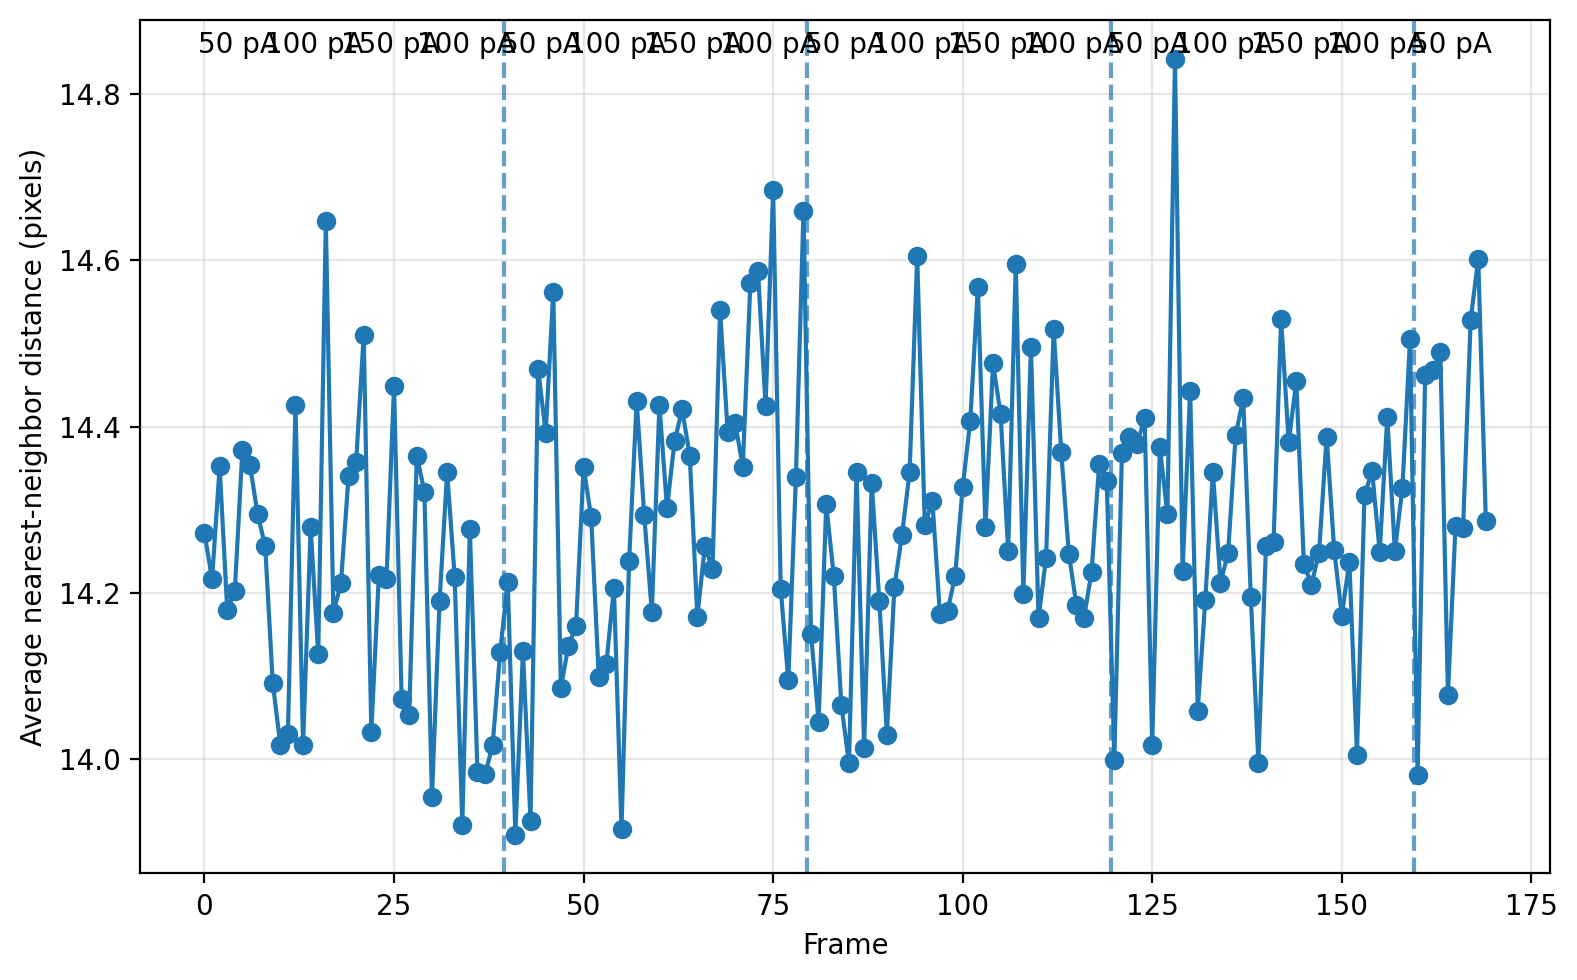

In [67]:
# ============================================================
# convert data
# ============================================================
meta_images = np.array(meta_images, dtype=object)
real_currents = np.array(real_currents)
frame_currents = np.array(frame_currents)
frame_times = np.array(frame_times)


# ============================================================
# compute NN distance for each frame
# ============================================================
avg_nn = []

for current_block in meta_images:
    for image in current_block:
        image = np.asarray(image, dtype=float)
        avg_nn.append(average_nn_distance(image))

avg_nn = np.array(avg_nn)


# ============================================================
# save data
# ============================================================
recipe = {
    "set_currents_pA": set_currents_pA,
    "frames_per_current": frames_per_current,
    "dwell_time_s": dwell_time_s,
    "imsize": imsize,
    "stabilization_time_s": stabilization_time_s,
    "timestamp": datetime.now().isoformat(),
}

np.savez(
    filename,
    images=meta_images,
    real_currents_pA=real_currents,
    frame_currents_pA=frame_currents,
    frame_times_s=frame_times,
    avg_nn_pixels=avg_nn,
    recipe=recipe,
)

print(f"\nSaved dataset to:\n{filename}")


# ============================================================
# plot results
# ============================================================
fig, ax1 = plt.subplots(figsize=(8, 5), dpi=200)

frames = np.arange(len(avg_nn))

ax1.plot(
    frames,
    avg_nn,
    marker="o",
    linewidth=1.5,
)

ax1.set_xlabel("Frame")
ax1.set_ylabel("Average nearest-neighbor distance (pixels)")
ax1.grid(True, alpha=0.3)


# ------------------------------------------------------------
# draw vertical lines wherever a new 50 pA cycle begins
# ------------------------------------------------------------
cycle_start_indices = np.where(
    (frame_currents == 50) &
    (np.roll(frame_currents, 1) != 50)
)[0]

# remove accidental detection at frame 0 if needed
cycle_start_indices = cycle_start_indices[cycle_start_indices > 0]

for idx in cycle_start_indices:
    ax1.axvline(
        idx - 0.5,
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
    )


# ------------------------------------------------------------
# label current values above regions
# ------------------------------------------------------------
unique_currents = []
region_centers = []

start = 0

for i in range(1, len(frame_currents) + 1):

    if i == len(frame_currents) or frame_currents[i] != frame_currents[i - 1]:

        stop = i

        current = frame_currents[start]

        unique_currents.append(current)
        region_centers.append((start + stop - 1) / 2)

        start = i

for x_center, c in zip(region_centers, unique_currents):

    ax1.text(
        x_center,
        np.nanmax(avg_nn),
        f"{c:.0f} pA",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

In [ ]:
# ----

In [82]:
mic.set_screen_current(200)

In [130]:
import os
import time
import numpy as np
from datetime import datetime


# ============================================================
# experiment recipe
# ============================================================
ramp_currents_pA = [50, 100, 150, 200]
recovery_current_pA = 50

frames_per_current = 10
recovery_frames = 10

pause_after_ramp_s = 60

dwell_time_s = 10e-6
imsize = 512
stabilization_time_s = 1

filename = os.path.join(savefile_path, "beam_ramp_50_100_150_200_pause60s_50_nofocus_3.npz")


# ============================================================
# run experiment
# ============================================================
meta_images = []
real_currents = []
frame_currents = []
frame_times = []
frame_labels = []

t0 = time.time()

# ------------------------------------------------------------
# 1) ramp upward: 50, 100, 150, 200 pA
# ------------------------------------------------------------
for c in ramp_currents_pA:

    print(f"\nSetting screen current to {c} pA...")
    mic.set_screen_current(c)

    time.sleep(stabilization_time_s)

    real_screen_current = mic.get_screen_current() 
    real_currents.append(real_screen_current)

    print(f"Measured current: {real_screen_current:.2f} pA")
    print("Autofocusing...")
    # mic.auto_focus()

    images_this_current = []

    for i in range(frames_per_current):
        print(f"  Acquiring frame {i+1}/{frames_per_current} at {c} pA")

        image, metadata = get_image(dwell=dwell_time_s, imsize=imsize)

        images_this_current.append(image)
        frame_currents.append(c)
        frame_times.append(time.time() - t0)
        frame_labels.append(f"{c}_pA_ramp")

    meta_images.append(images_this_current)


# ------------------------------------------------------------
# 2) pause scanning for recovery
# ------------------------------------------------------------
print(f"\nPausing scanning for {pause_after_ramp_s} seconds...")
time.sleep(pause_after_ramp_s)


# ------------------------------------------------------------
# 3) return to 50 pA and acquire recovery frames
# ------------------------------------------------------------
print(f"\nSetting screen current to {recovery_current_pA} pA...")
mic.set_screen_current(recovery_current_pA)

time.sleep(stabilization_time_s)

real_screen_current = mic.get_screen_current() * 1e12
real_currents.append(real_screen_current)

print(f"Measured current: {real_screen_current:.2f} pA")
print("Autofocusing...")
# mic.auto_focus()

recovery_images = []

for i in range(recovery_frames):
    print(f"  Acquiring recovery frame {i+1}/{recovery_frames} at {recovery_current_pA} pA")

    image, metadata = get_image(dwell=dwell_time_s, imsize=imsize)

    recovery_images.append(image)
    frame_currents.append(recovery_current_pA)
    frame_times.append(time.time() - t0)
    frame_labels.append(f"{recovery_current_pA}_pA_recovery")

meta_images.append(recovery_images)


# ============================================================
# convert and save
# ============================================================
meta_images = np.array(meta_images, dtype=object)
real_currents = np.array(real_currents)
frame_currents = np.array(frame_currents)
frame_times = np.array(frame_times)
frame_labels = np.array(frame_labels)

recipe = {
    "ramp_currents_pA": ramp_currents_pA,
    "recovery_current_pA": recovery_current_pA,
    "frames_per_current": frames_per_current,
    "recovery_frames": recovery_frames,
    "pause_after_ramp_s": pause_after_ramp_s,
    "dwell_time_s": dwell_time_s,
    "imsize": imsize,
    "stabilization_time_s": stabilization_time_s,
    "autofocus_after_each_current_switch": True,
    "timestamp": datetime.now().isoformat(),
}

np.savez(
    filename,
    images=meta_images,
    real_currents_pA=real_currents,
    frame_currents_pA=frame_currents,
    frame_times_s=frame_times,
    frame_labels=frame_labels,
    recipe=recipe,
)

print(f"\nSaved dataset to:\n{filename}")


Setting screen current to 50 pA...
Measured current: 51.05 pA
Autofocusing...
  Acquiring frame 1/10 at 50 pA
  Acquiring frame 2/10 at 50 pA
  Acquiring frame 3/10 at 50 pA
  Acquiring frame 4/10 at 50 pA
  Acquiring frame 5/10 at 50 pA
  Acquiring frame 6/10 at 50 pA
  Acquiring frame 7/10 at 50 pA
  Acquiring frame 8/10 at 50 pA
  Acquiring frame 9/10 at 50 pA
  Acquiring frame 10/10 at 50 pA

Setting screen current to 100 pA...
Measured current: 102.32 pA
Autofocusing...
  Acquiring frame 1/10 at 100 pA
  Acquiring frame 2/10 at 100 pA
  Acquiring frame 3/10 at 100 pA
  Acquiring frame 4/10 at 100 pA
  Acquiring frame 5/10 at 100 pA
  Acquiring frame 6/10 at 100 pA
  Acquiring frame 7/10 at 100 pA
  Acquiring frame 8/10 at 100 pA
  Acquiring frame 9/10 at 100 pA
  Acquiring frame 10/10 at 100 pA

Setting screen current to 150 pA...
Measured current: 152.68 pA
Autofocusing...
  Acquiring frame 1/10 at 150 pA
  Acquiring frame 2/10 at 150 pA
  Acquiring frame 3/10 at 150 pA
  Acquir

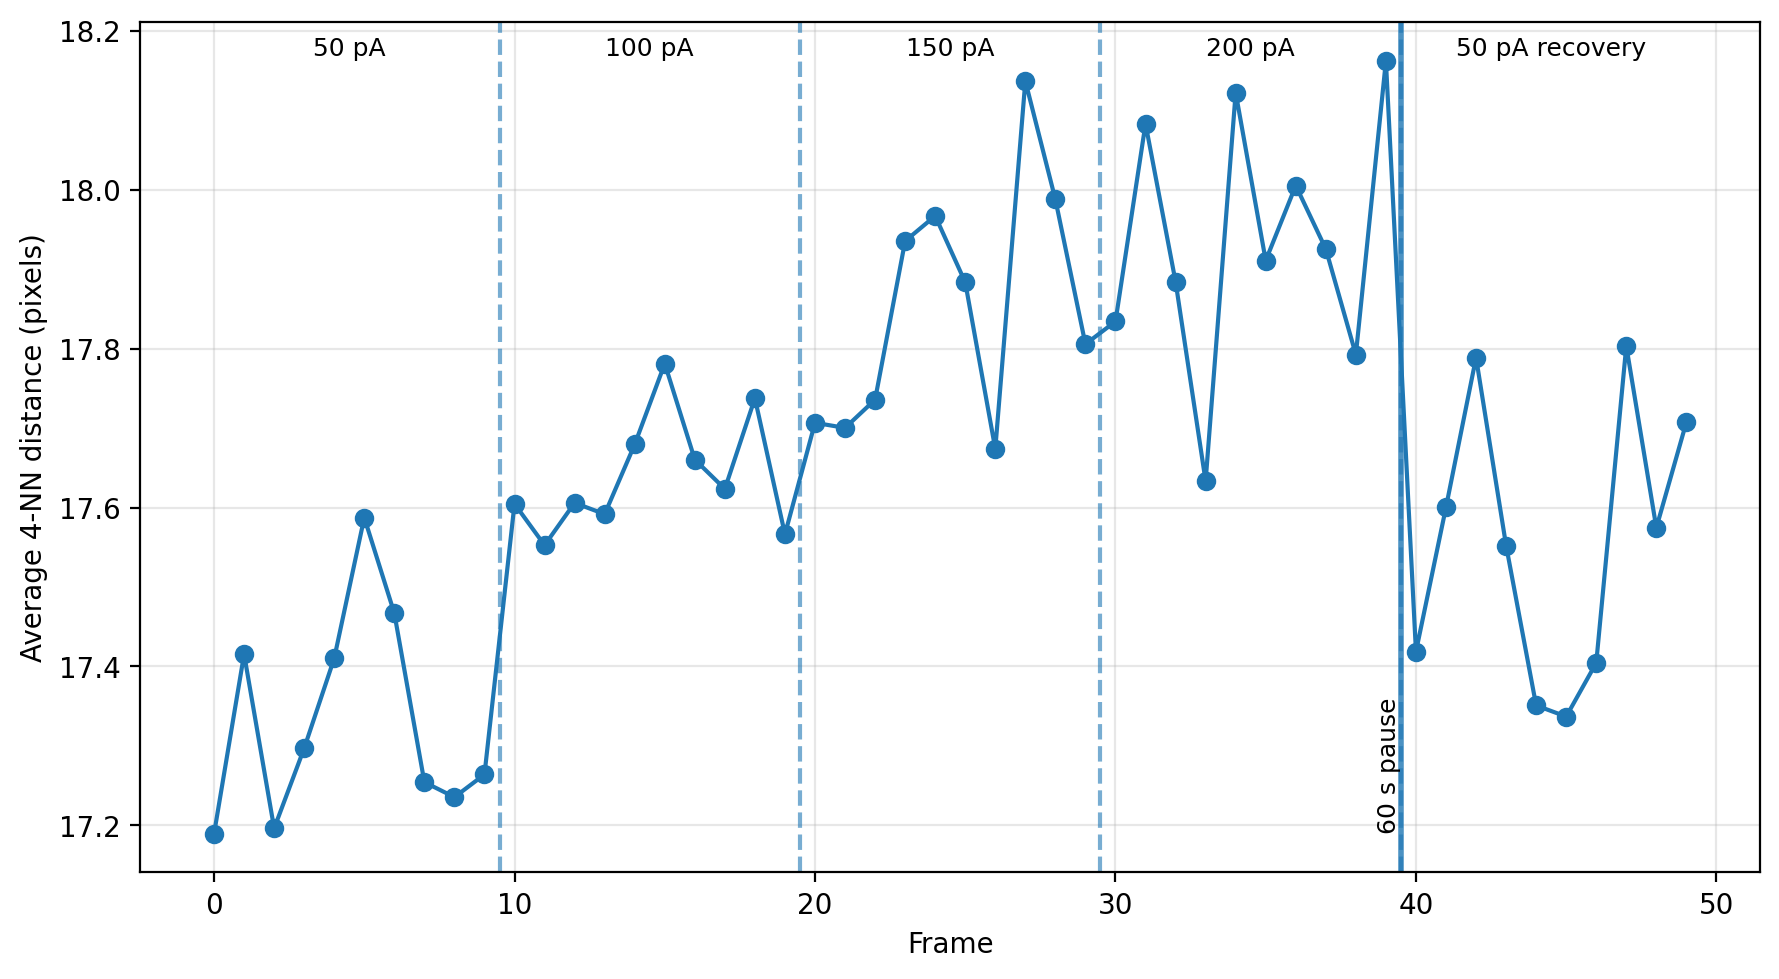

In [131]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree


# ============================================================
# helper: average 4-nearest-neighbor distance
# ============================================================
def average_4nn_distance(image, n_nn=1):

    blobs = detect_blobs(image)

    if blobs is None or len(blobs) < n_nn + 1:
        return np.nan

    tree = cKDTree(blobs)

    # k = n_nn + 1 because first neighbor is self
    dists, _ = tree.query(blobs, k=n_nn + 1)

    # remove self-distance column
    nn_dists = dists[:, 1:n_nn + 1]

    # average over all neighbors and all atoms
    return np.mean(nn_dists)


# ============================================================
# compute 4-NN distance for each frame
# ============================================================
avg_nn = []

for current_block in meta_images:
    for image in current_block:

        image = np.asarray(image, dtype=float)

        avg_nn.append(
            average_4nn_distance(image, n_nn=1)
        )

avg_nn = np.array(avg_nn)

frames = np.arange(len(avg_nn))


# ============================================================
# plot
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5), dpi=200)

ax.plot(
    frames,
    avg_nn,
    marker="o",
    linewidth=1.5,
)

ax.set_xlabel("Frame")
ax.set_ylabel("Average 4-NN distance (pixels)")
ax.grid(True, alpha=0.3)


# ------------------------------------------------------------
# vertical lines at each new current block
# ------------------------------------------------------------
block_lengths = [frames_per_current] * len(ramp_currents_pA) + [recovery_frames]
block_currents = ramp_currents_pA + [recovery_current_pA]
block_labels = [f"{c} pA" for c in ramp_currents_pA] + [f"{recovery_current_pA} pA recovery"]

starts = np.cumsum([0] + block_lengths[:-1])

for start in starts[1:]:
    ax.axvline(
        start - 0.5,
        linestyle="--",
        linewidth=1.5,
        alpha=0.6,
    )


# ------------------------------------------------------------
# label current regions
# ------------------------------------------------------------
y_text = np.nanmax(avg_nn)

for start, length, label in zip(starts, block_lengths, block_labels):

    x_center = start + length / 2 - 0.5

    ax.text(
        x_center,
        y_text,
        label,
        ha="center",
        va="bottom",
        fontsize=9,
    )


# ------------------------------------------------------------
# mark pause
# ------------------------------------------------------------
pause_start = sum([frames_per_current] * len(ramp_currents_pA))

ax.axvline(
    pause_start - 0.5,
    linestyle="-",
    linewidth=2,
    alpha=0.8,
)

ax.text(
    pause_start - 0.5,
    np.nanmin(avg_nn),
    "60 s pause",
    ha="right",
    va="bottom",
    rotation=90,
    fontsize=9,
)

plt.tight_layout()
plt.show()

In [85]:
# --------------
mic.set_screen_current(100)

In [88]:
import os
import time
import numpy as np
from datetime import datetime


# ============================================================
# experiment recipe
# ============================================================
n_cycles = 3

ramp_currents_pA = [50, 100, 150, 200]
recovery_current_pA = 50

frames_per_current = 10
recovery_frames = 10

pause_after_ramp_s = 60

dwell_time_s = 10e-6
imsize = 512
stabilization_time_s = 1

filename = os.path.join(
    savefile_path,
    "beam_ramp_50_100_150_200_pause60s_50_3cycles.npz"
)


# ============================================================
# run experiment
# ============================================================
meta_images = []
real_currents = []
frame_currents = []
frame_times = []
frame_labels = []
frame_cycle = []
block_labels = []

t0 = time.time()


for cycle in range(n_cycles):

    cycle_number = cycle + 1

    print(f"\n================ Cycle {cycle_number}/{n_cycles} ================")

    # --------------------------------------------------------
    # ramp upward: 50, 100, 150, 200 pA
    # --------------------------------------------------------
    for c in ramp_currents_pA:

        print(f"\nSetting screen current to {c} pA...")
        mic.set_screen_current(c)

        time.sleep(stabilization_time_s)

        real_screen_current = mic.get_screen_current() * 1e12
        real_currents.append(real_screen_current)

        print(f"Measured current: {real_screen_current:.2f} pA")
        print("Autofocusing...")
        mic.auto_focus()

        images_this_current = []
        block_label = f"cycle{cycle_number}_{c}_pA_ramp"

        for i in range(frames_per_current):
            print(
                f"  Cycle {cycle_number}: acquiring frame "
                f"{i+1}/{frames_per_current} at {c} pA"
            )

            image, metadata = get_image(dwell=dwell_time_s, imsize=imsize)

            images_this_current.append(image)
            frame_currents.append(c)
            frame_times.append(time.time() - t0)
            frame_labels.append(block_label)
            frame_cycle.append(cycle_number)

        meta_images.append(images_this_current)
        block_labels.append(block_label)

    # --------------------------------------------------------
    # pause scanning for recovery
    # --------------------------------------------------------
    print(f"\nCycle {cycle_number}: pausing scanning for {pause_after_ramp_s} seconds...")
    time.sleep(pause_after_ramp_s)

    # --------------------------------------------------------
    # recovery at 50 pA
    # --------------------------------------------------------
    print(f"\nSetting screen current to {recovery_current_pA} pA...")
    mic.set_screen_current(recovery_current_pA)

    time.sleep(stabilization_time_s)

    real_screen_current = mic.get_screen_current() * 1e12
    real_currents.append(real_screen_current)

    print(f"Measured current: {real_screen_current:.2f} pA")
    print("Autofocusing...")
    mic.auto_focus()

    recovery_images = []
    block_label = f"cycle{cycle_number}_{recovery_current_pA}_pA_recovery"

    for i in range(recovery_frames):
        print(
            f"  Cycle {cycle_number}: acquiring recovery frame "
            f"{i+1}/{recovery_frames} at {recovery_current_pA} pA"
        )

        image, metadata = get_image(dwell=dwell_time_s, imsize=imsize)

        recovery_images.append(image)
        frame_currents.append(recovery_current_pA)
        frame_times.append(time.time() - t0)
        frame_labels.append(block_label)
        frame_cycle.append(cycle_number)

    meta_images.append(recovery_images)
    block_labels.append(block_label)


# ============================================================
# convert and save
# ============================================================
meta_images = np.array(meta_images, dtype=object)
real_currents = np.array(real_currents)
frame_currents = np.array(frame_currents)
frame_times = np.array(frame_times)
frame_labels = np.array(frame_labels)
frame_cycle = np.array(frame_cycle)
block_labels = np.array(block_labels)

recipe = {
    "n_cycles": n_cycles,
    "ramp_currents_pA": ramp_currents_pA,
    "recovery_current_pA": recovery_current_pA,
    "frames_per_current": frames_per_current,
    "recovery_frames": recovery_frames,
    "pause_after_ramp_s": pause_after_ramp_s,
    "dwell_time_s": dwell_time_s,
    "imsize": imsize,
    "stabilization_time_s": stabilization_time_s,
    "autofocus_after_each_current_switch": True,
    "timestamp": datetime.now().isoformat(),
}

np.savez(
    filename,
    images=meta_images,
    real_currents_pA=real_currents,
    frame_currents_pA=frame_currents,
    frame_times_s=frame_times,
    frame_labels=frame_labels,
    frame_cycle=frame_cycle,
    block_labels=block_labels,
    recipe=recipe,
)

print(f"\nSaved dataset to:\n{filename}")


================ Cycle 1/3 ================

Setting screen current to 50 pA...
Measured current: 53309518843.89 pA
Autofocusing...
  Cycle 1: acquiring frame 1/10 at 50 pA
  Cycle 1: acquiring frame 2/10 at 50 pA
  Cycle 1: acquiring frame 3/10 at 50 pA
  Cycle 1: acquiring frame 4/10 at 50 pA
  Cycle 1: acquiring frame 5/10 at 50 pA
  Cycle 1: acquiring frame 6/10 at 50 pA
  Cycle 1: acquiring frame 7/10 at 50 pA
  Cycle 1: acquiring frame 8/10 at 50 pA
  Cycle 1: acquiring frame 9/10 at 50 pA
  Cycle 1: acquiring frame 10/10 at 50 pA

Setting screen current to 100 pA...
Measured current: 108188705444335.94 pA
Autofocusing...
  Cycle 1: acquiring frame 1/10 at 100 pA
  Cycle 1: acquiring frame 2/10 at 100 pA
  Cycle 1: acquiring frame 3/10 at 100 pA
  Cycle 1: acquiring frame 4/10 at 100 pA
  Cycle 1: acquiring frame 5/10 at 100 pA
  Cycle 1: acquiring frame 6/10 at 100 pA
  Cycle 1: acquiring frame 7/10 at 100 pA
  Cycle 1: acquiring frame 8/10 at 100 pA
  Cycle 1: acquiring frame 

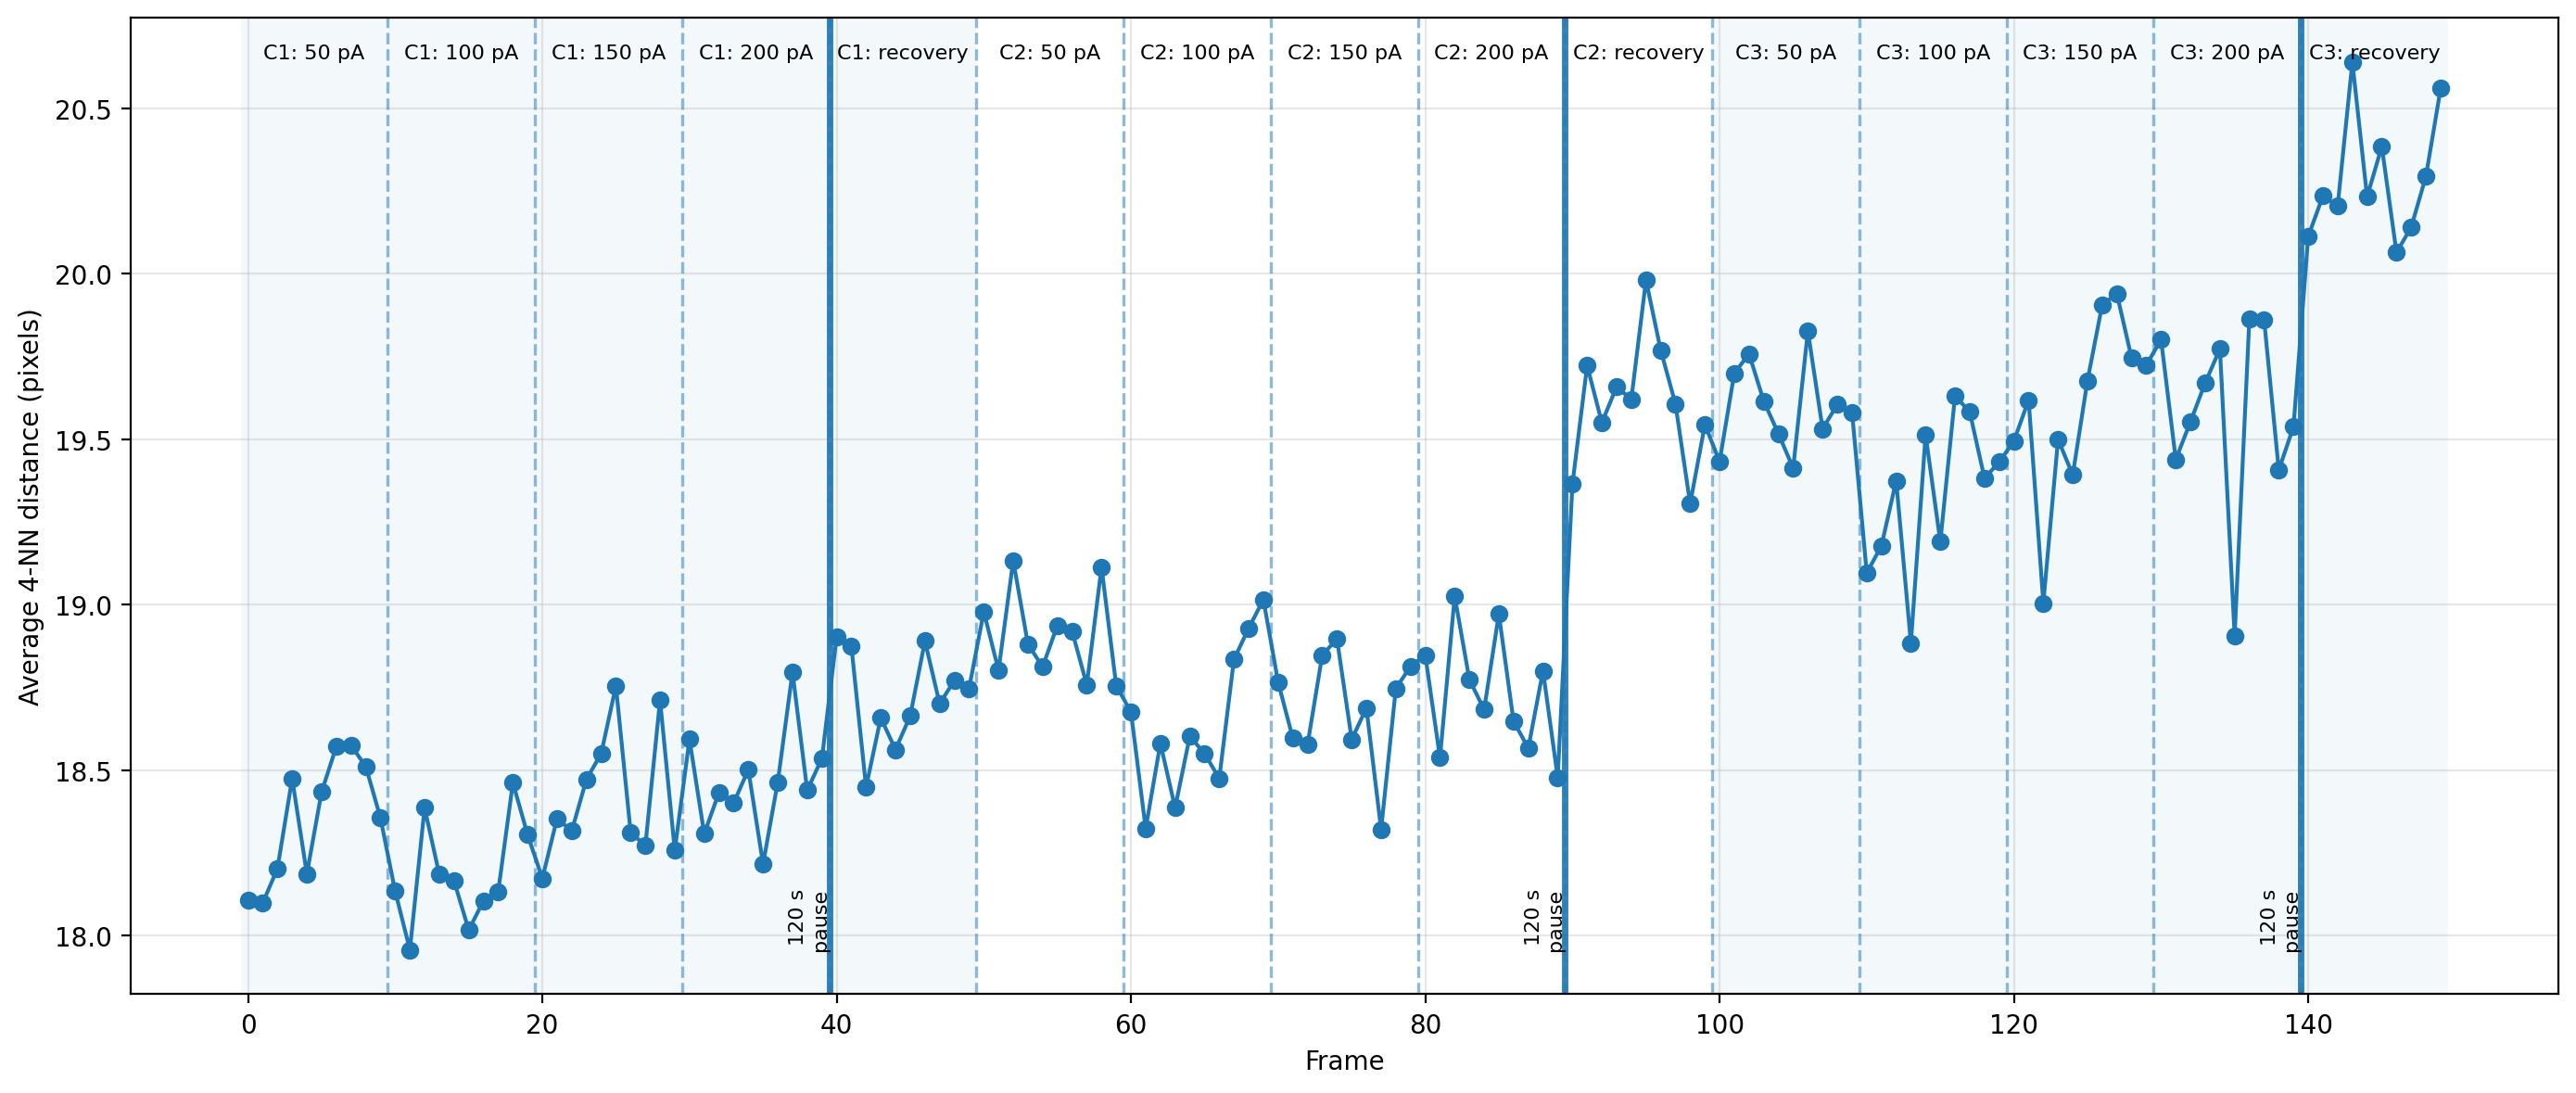

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree


# ============================================================
# helper: average 4-nearest-neighbor distance
# ============================================================
def average_4nn_distance(image, n_nn=4):

    blobs = detect_blobs(image)

    if blobs is None or len(blobs) < n_nn + 1:
        return np.nan

    tree = cKDTree(blobs)

    # first neighbor is self
    dists, _ = tree.query(blobs, k=n_nn + 1)

    # remove self-distance
    nn_dists = dists[:, 1:n_nn + 1]

    return np.mean(nn_dists)


# ============================================================
# compute 4-NN distance for each frame
# ============================================================
avg_nn = []

for current_block in meta_images:

    for image in current_block:

        image = np.asarray(image, dtype=float)

        avg_nn.append(
            average_4nn_distance(image, n_nn=4)
        )

avg_nn = np.array(avg_nn)

frames = np.arange(len(avg_nn))


# ============================================================
# plot
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6), dpi=200)

ax.plot(
    frames,
    avg_nn,
    marker="o",
    linewidth=1.5,
)

ax.set_xlabel("Frame")
ax.set_ylabel("Average 4-NN distance (pixels)")
ax.grid(True, alpha=0.3)


# ============================================================
# construct block information
# ============================================================
block_lengths = []

for cycle in range(n_cycles):

    # 50,100,150,200 ramps
    for _ in ramp_currents_pA:
        block_lengths.append(frames_per_current)

    # recovery block
    block_lengths.append(recovery_frames)

block_currents = (
    ramp_currents_pA + [recovery_current_pA]
) * n_cycles

block_names = []

for cycle in range(n_cycles):

    cycle_number = cycle + 1

    for c in ramp_currents_pA:
        block_names.append(f"C{cycle_number}: {c} pA")

    block_names.append(f"C{cycle_number}: recovery")


# ============================================================
# block start indices
# ============================================================
starts = np.cumsum([0] + block_lengths[:-1])


# ============================================================
# draw vertical lines
# ============================================================
for start in starts[1:]:

    ax.axvline(
        start - 0.5,
        linestyle="--",
        linewidth=1.2,
        alpha=0.5,
    )


# ============================================================
# highlight recovery starts
# ============================================================
for i, (start, current) in enumerate(zip(starts, block_currents)):

    is_recovery = (
        current == recovery_current_pA and
        (i % (len(ramp_currents_pA) + 1)) == len(ramp_currents_pA)
    )

    if is_recovery:

        ax.axvline(
            start - 0.5,
            linestyle="-",
            linewidth=2.5,
            alpha=0.9,
        )

        ax.text(
            start - 0.5,
            np.nanmin(avg_nn),
            f"120 s\npause",
            rotation=90,
            ha="right",
            va="bottom",
            fontsize=8,
        )


# ============================================================
# label regions
# ============================================================
y_text = np.nanmax(avg_nn)

for start, length, label in zip(starts, block_lengths, block_names):

    x_center = start + length / 2 - 0.5

    ax.text(
        x_center,
        y_text,
        label,
        ha="center",
        va="bottom",
        fontsize=8,
    )


# ============================================================
# shade alternating cycles
# ============================================================
frames_per_cycle = (
    len(ramp_currents_pA) * frames_per_current
    + recovery_frames
)

for cycle in range(n_cycles):

    if cycle % 2 == 0:

        x0 = cycle * frames_per_cycle
        x1 = x0 + frames_per_cycle

        ax.axvspan(
            x0 - 0.5,
            x1 - 0.5,
            alpha=0.05,
        )


plt.tight_layout()
plt.show()

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks


def fft_radial_peak_spacing(
    image,
    pixel_size=1.0,
    min_radius_px=8,
    max_radius_px=None,
    fine_smooth_sigma=1,
    background_sigma=20,
    prominence=0.03,
    distance=3,
    cross_width=3,   # width of removed FFT cross
    plot=False,
):
    """
    Estimate lattice spacing from FFT radial peaks after:
      1) removing FFT cross artifacts
      2) subtracting smooth radial background
      3) detecting residual peaks
    """

    # ========================================================
    # image preparation
    # ========================================================
    im = np.asarray(image, dtype=float)
    im = np.nan_to_num(im)

    im = im - np.mean(im)

    wy = np.hanning(im.shape[0])
    wx = np.hanning(im.shape[1])

    window = np.outer(wy, wx)

    im_win = im * window

    # ========================================================
    # FFT
    # ========================================================
    fft = np.fft.fftshift(np.fft.fft2(im_win))

    power = np.abs(fft) ** 2
    power = np.log1p(power)

    # ========================================================
    # REMOVE FFT CROSS ARTIFACTS
    # ========================================================
    cy, cx = np.array(power.shape) // 2

    # horizontal streak
    power[
        cy - cross_width : cy + cross_width + 1,
        :
    ] = 0

    # vertical streak
    power[
        :,
        cx - cross_width : cx + cross_width + 1
    ] = 0

    # ========================================================
    # radial average
    # ========================================================
    y, x = np.indices(power.shape)

    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    r_int = r.astype(int)

    radial_sum = np.bincount(
        r_int.ravel(),
        weights=power.ravel()
    )

    radial_count = np.bincount(r_int.ravel())

    radial_profile = radial_sum / np.maximum(radial_count, 1)

    # ========================================================
    # smooth + subtract background
    # ========================================================
    profile_smooth = gaussian_filter1d(
        radial_profile,
        sigma=fine_smooth_sigma
    )

    background = gaussian_filter1d(
        profile_smooth,
        sigma=background_sigma
    )

    residual = profile_smooth - background

    # normalize residual
    residual = residual - np.nanmin(residual)

    if np.nanmax(residual) > 0:
        residual = residual / np.nanmax(residual)

    # ========================================================
    # restrict search region
    # ========================================================
    if max_radius_px is None:
        max_radius_px = len(residual) // 2

    search = residual.copy()

    search[:min_radius_px] = 0
    search[max_radius_px:] = 0

    # ========================================================
    # find peaks
    # ========================================================
    peaks, props = find_peaks(
        search,
        prominence=prominence,
        distance=distance,
    )

    if len(peaks) == 0:
        return np.nan, np.nan, np.nan, radial_profile, residual, peaks

    prominences = props["prominences"]

    best_peak = peaks[np.argmax(prominences)]

    # ========================================================
    # convert FFT radius -> real-space spacing
    # ========================================================
    image_size_px = np.mean(im.shape)

    spacing_px = image_size_px / best_peak
    spacing_real = spacing_px * pixel_size

    # ========================================================
    # plotting
    # ========================================================
    if plot:

        radii = np.arange(len(radial_profile))

        fig, ax = plt.subplots(figsize=(8, 4), dpi=200)

        ax.plot(
            radii,
            radial_profile / np.nanmax(radial_profile),
            label="raw radial FFT"
        )

        ax.plot(
            radii,
            background / np.nanmax(background),
            label="background"
        )

        ax.plot(
            radii,
            residual,
            label="residual"
        )

        ax.scatter(
            peaks,
            residual[peaks],
            s=30,
            label="candidate peaks"
        )

        ax.axvline(
            best_peak,
            linestyle="--",
            linewidth=2,
            label=f"selected peak r={best_peak}"
        )

        ax.set_xlim(0, max_radius_px)

        ax.set_xlabel("FFT radius (pixels)")
        ax.set_ylabel("Normalized intensity")

        ax.grid(True, alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.show()

    return (
        spacing_px,
        spacing_real,
        best_peak,
        radial_profile,
        residual,
        peaks,
    )

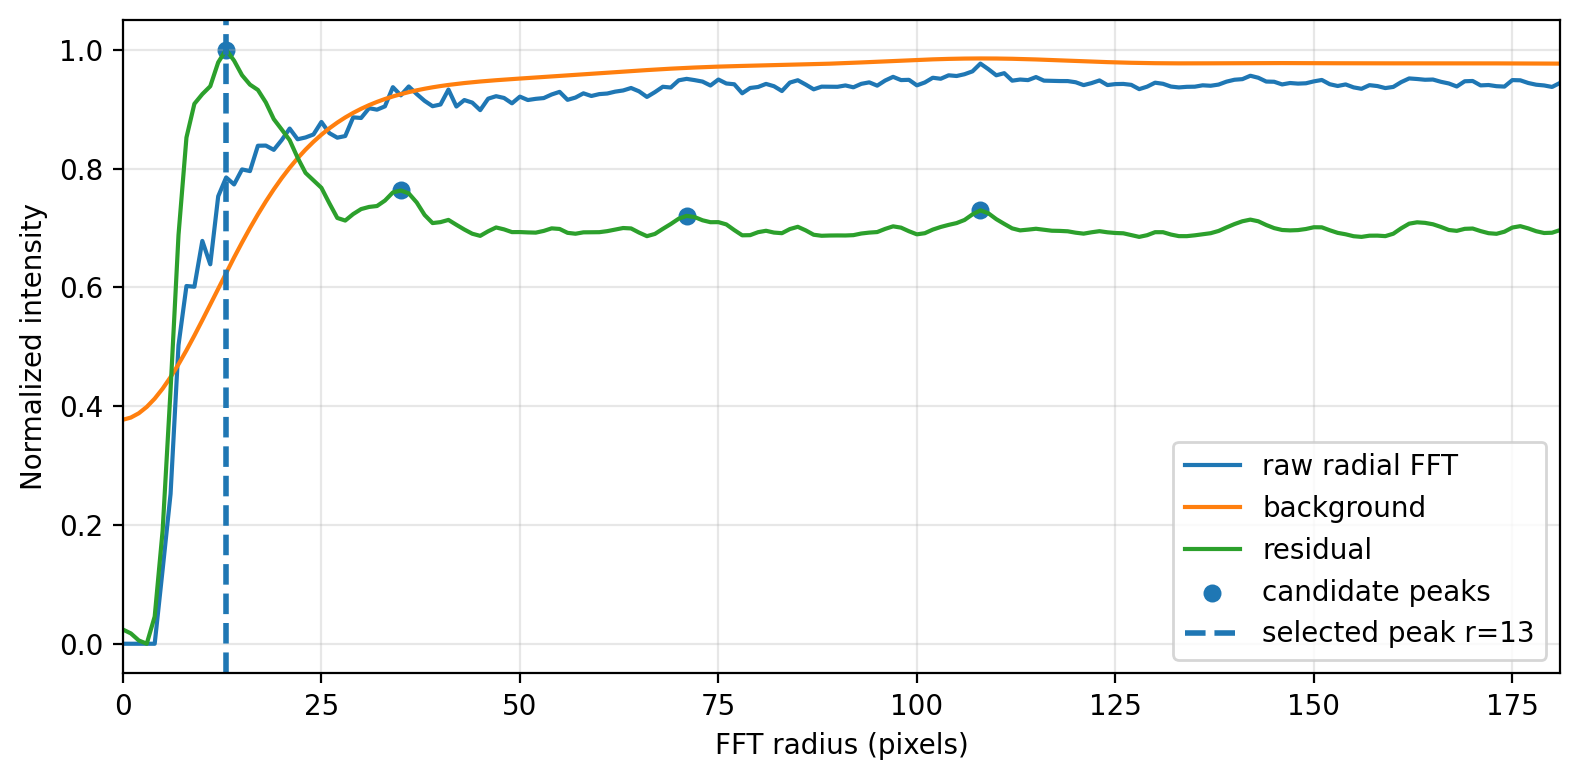

Selected FFT peak radius: 13
Estimated spacing: 39.38 pixels


In [115]:
spacing_px, spacing_real, peak_radius, radial_profile, residual, peaks = fft_radial_peak_spacing(
    meta_images[0][2],
    pixel_size=1.0,
    min_radius_px=10,
    max_radius_px=None,
    background_sigma=10,
    prominence=0.03,
    plot=True,
)

print(f"Selected FFT peak radius: {peak_radius}")
print(f"Estimated spacing: {spacing_px:.2f} pixels")

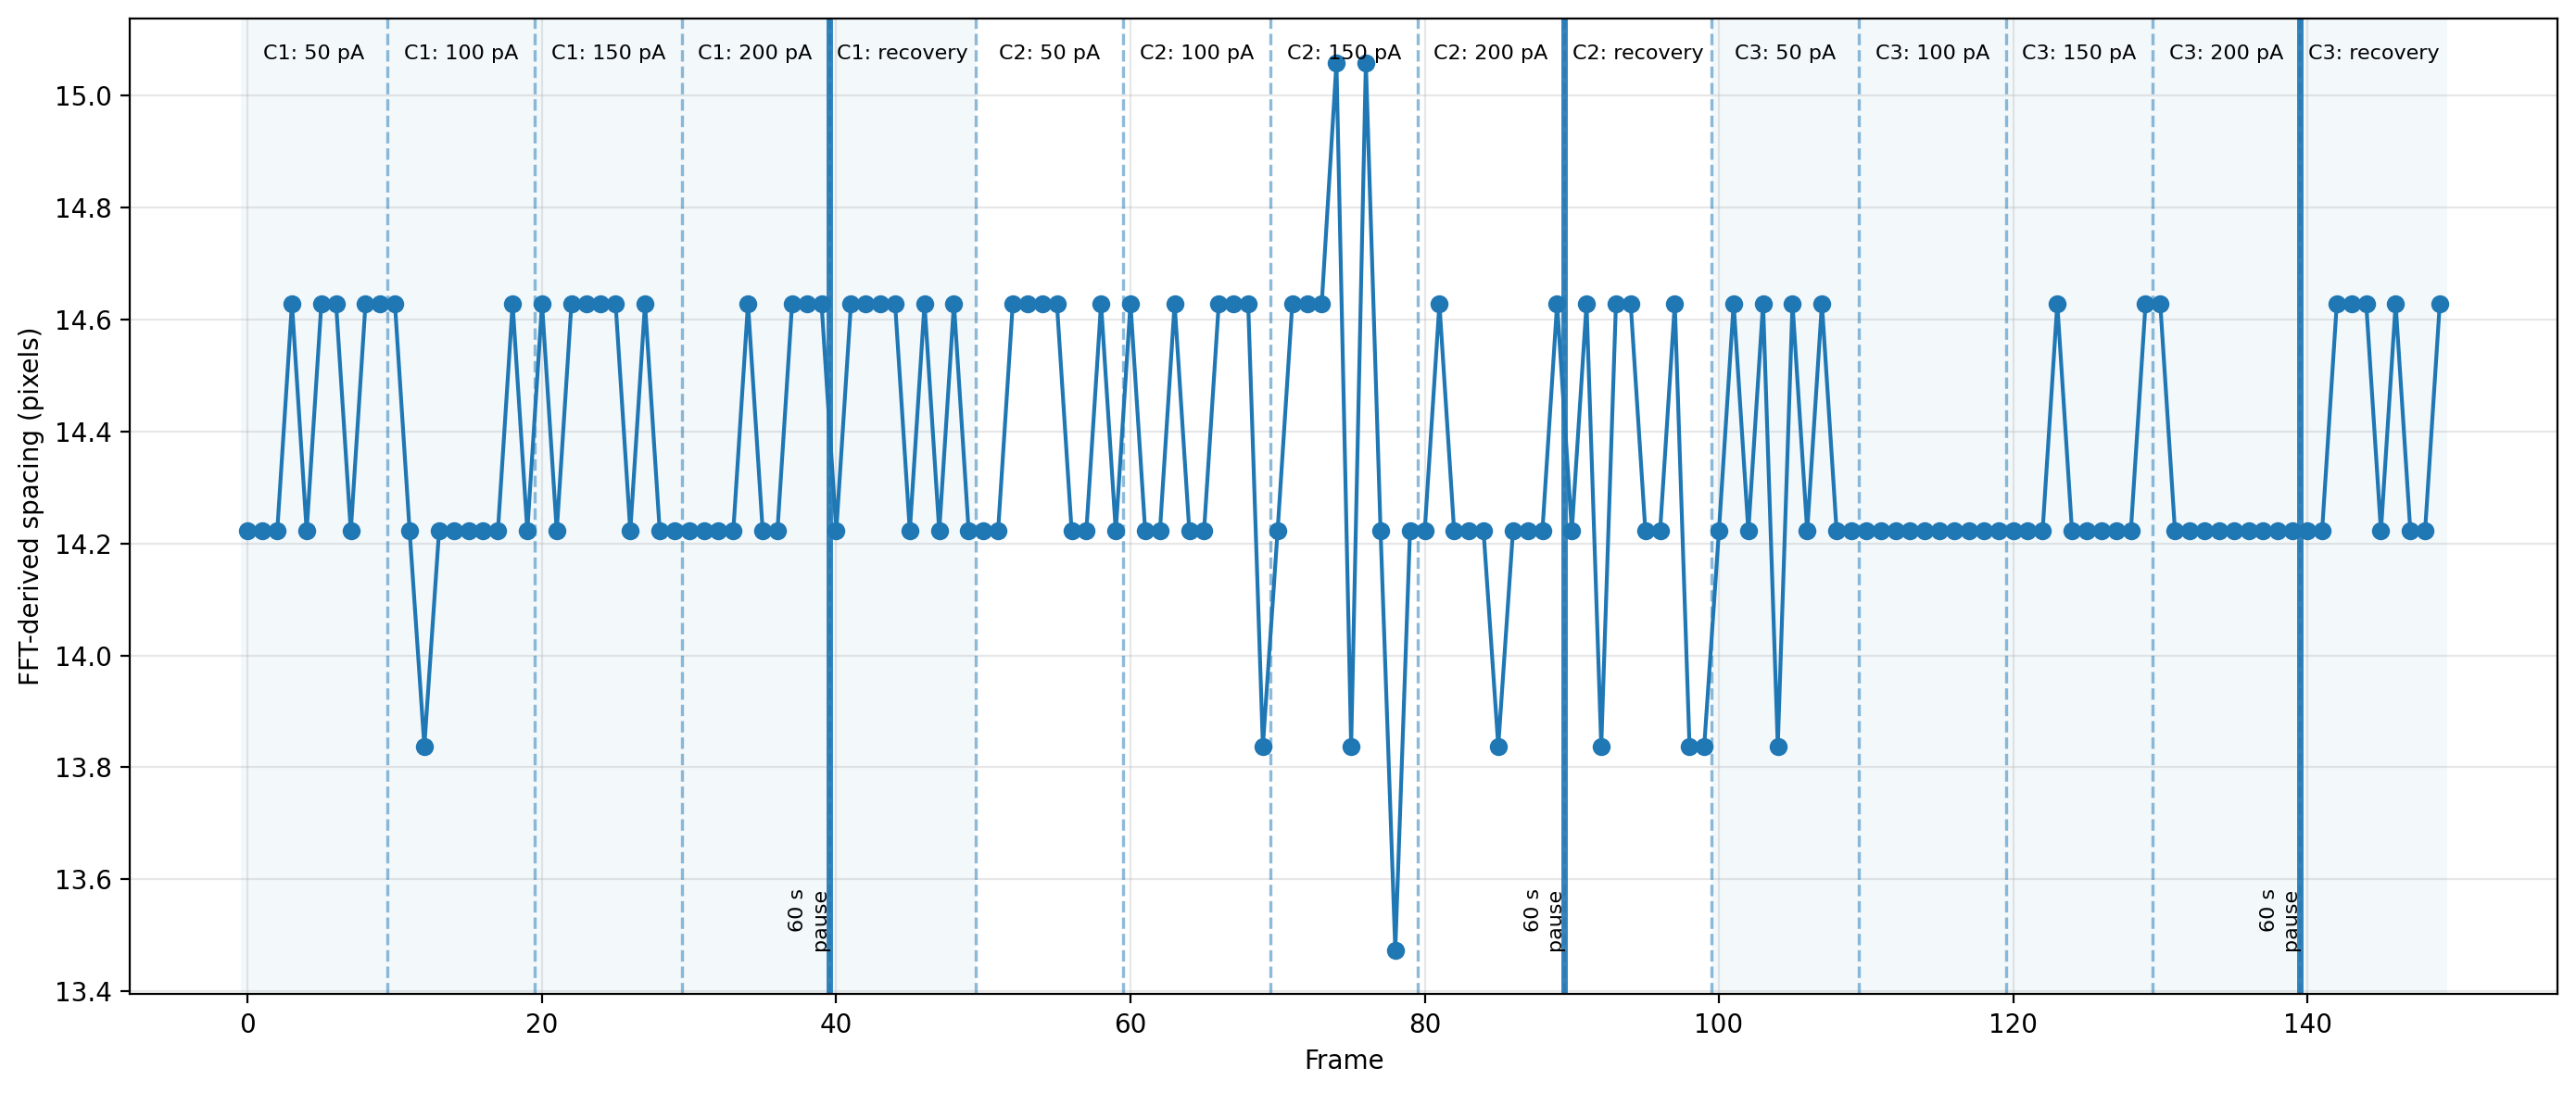

In [109]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# compute FFT-derived spacing for each frame
# ============================================================
fft_nn = []
fft_peak_radii = []

for current_block in meta_images:

    for image in current_block:

        image = np.asarray(image, dtype=float)

        spacing_px, spacing_real, peak_radius, radial_profile, residual, peaks = fft_radial_peak_spacing(
            image,
            pixel_size=1.0,
            min_radius_px=20,
            max_radius_px=50,
            background_sigma=20,
            prominence=0.03,
            plot=False,
        )

        fft_nn.append(spacing_px)
        fft_peak_radii.append(peak_radius)

fft_nn = np.array(fft_nn)
fft_peak_radii = np.array(fft_peak_radii)

frames = np.arange(len(fft_nn))


# ============================================================
# plot FFT-derived spacing
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6), dpi=200)

ax.plot(
    frames,
    fft_nn,
    marker="o",
    linewidth=1.5,
)

ax.set_xlabel("Frame")
ax.set_ylabel("FFT-derived spacing (pixels)")
ax.grid(True, alpha=0.3)


# ============================================================
# construct block information
# ============================================================
block_lengths = []

for cycle in range(n_cycles):

    for _ in ramp_currents_pA:
        block_lengths.append(frames_per_current)

    block_lengths.append(recovery_frames)

block_currents = (
    ramp_currents_pA + [recovery_current_pA]
) * n_cycles

block_names = []

for cycle in range(n_cycles):

    cycle_number = cycle + 1

    for c in ramp_currents_pA:
        block_names.append(f"C{cycle_number}: {c} pA")

    block_names.append(f"C{cycle_number}: recovery")


starts = np.cumsum([0] + block_lengths[:-1])


# ============================================================
# draw vertical lines at block boundaries
# ============================================================
for start in starts[1:]:

    ax.axvline(
        start - 0.5,
        linestyle="--",
        linewidth=1.2,
        alpha=0.5,
    )


# ============================================================
# highlight recovery starts after pause
# ============================================================
for i, (start, current) in enumerate(zip(starts, block_currents)):

    is_recovery = (
        current == recovery_current_pA
        and (i % (len(ramp_currents_pA) + 1)) == len(ramp_currents_pA)
    )

    if is_recovery:

        ax.axvline(
            start - 0.5,
            linestyle="-",
            linewidth=2.5,
            alpha=0.9,
        )

        ax.text(
            start - 0.5,
            np.nanmin(fft_nn),
            f"{pause_after_ramp_s} s\npause",
            rotation=90,
            ha="right",
            va="bottom",
            fontsize=8,
        )


# ============================================================
# label regions
# ============================================================
y_text = np.nanmax(fft_nn)

for start, length, label in zip(starts, block_lengths, block_names):

    x_center = start + length / 2 - 0.5

    ax.text(
        x_center,
        y_text,
        label,
        ha="center",
        va="bottom",
        fontsize=8,
    )


# ============================================================
# shade alternating cycles
# ============================================================
frames_per_cycle = (
    len(ramp_currents_pA) * frames_per_current
    + recovery_frames
)

for cycle in range(n_cycles):

    if cycle % 2 == 0:

        x0 = cycle * frames_per_cycle
        x1 = x0 + frames_per_cycle

        ax.axvspan(
            x0 - 0.5,
            x1 - 0.5,
            alpha=0.05,
        )


plt.tight_layout()
plt.show()